# Procesamiento de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

## a) Limpieza y preparación de los datos

--- a) Cargando y preparando datos ---
Datos de entrenamiento: 229 semanas
Datos de prueba: 40 semanas


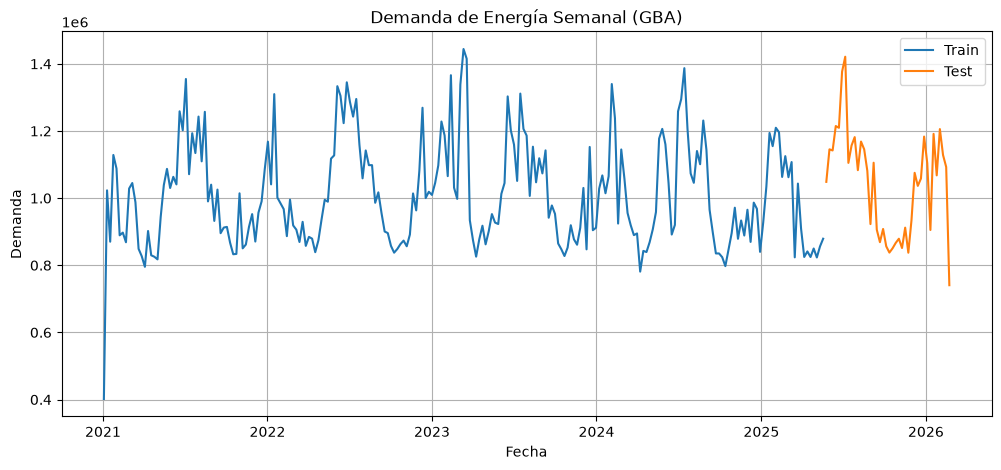

In [22]:
print("--- a) Cargando y preparando datos ---")
# Cargar datos (asegúrate de que el archivo esté en la misma carpeta que el notebook)
df = pd.read_csv('demanda_temp_aparente.csv', sep=';')

# Convertir FECHA a datetime y establecerla como índice
df['FECHA'] = pd.to_datetime(df['FECHA'])
df.set_index('FECHA', inplace=True)

# Agruparemos (resample) los datos de forma SEMANAL para suavizar la serie
# y facilitar que los modelos capturen la tendencia y estacionalidad anual.
# Sumamos la demanda semanal y promediamos la temperatura.
df['ES_FERIADO'] = (df['TIPO_DIA'].isin(['F', 'D'])).astype(int)

df_weekly = df.resample('W').agg({
    'DEMANDA_GBA': 'sum',
    'TEMP_APARENTE_AVG': 'mean',
    'ES_FERIADO': 'sum'
})

df_weekly.rename(columns={'ES_FERIADO': 'CANT_FERIADOS'}, inplace=True)


df_weekly['TEMP_APARENTE_AVG_2'] = df_weekly['TEMP_APARENTE_AVG'] ** 2

# Separar en conjunto de Entrenamiento (Train) y Prueba (Test)
# Usaremos el último 15% de los datos para evaluar los pronósticos
test_size = int(len(df_weekly) * 0.15)
train = df_weekly.iloc[:-test_size].copy()
test = df_weekly.iloc[-test_size:].copy()

print(f"Datos de entrenamiento: {len(train)} semanas")
print(f"Datos de prueba: {len(test)} semanas")

# Gráfica de la serie original
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['DEMANDA_GBA'], label='Train')
plt.plot(test.index, test['DEMANDA_GBA'], label='Test')
plt.title('Demanda de Energía Semanal (GBA)')
plt.xlabel('Fecha')
plt.ylabel('Demanda')
plt.legend()
plt.grid(True)
plt.show()


Descomposición estacional de la serie temporal

=== Descomposición de la serie de demanda ===


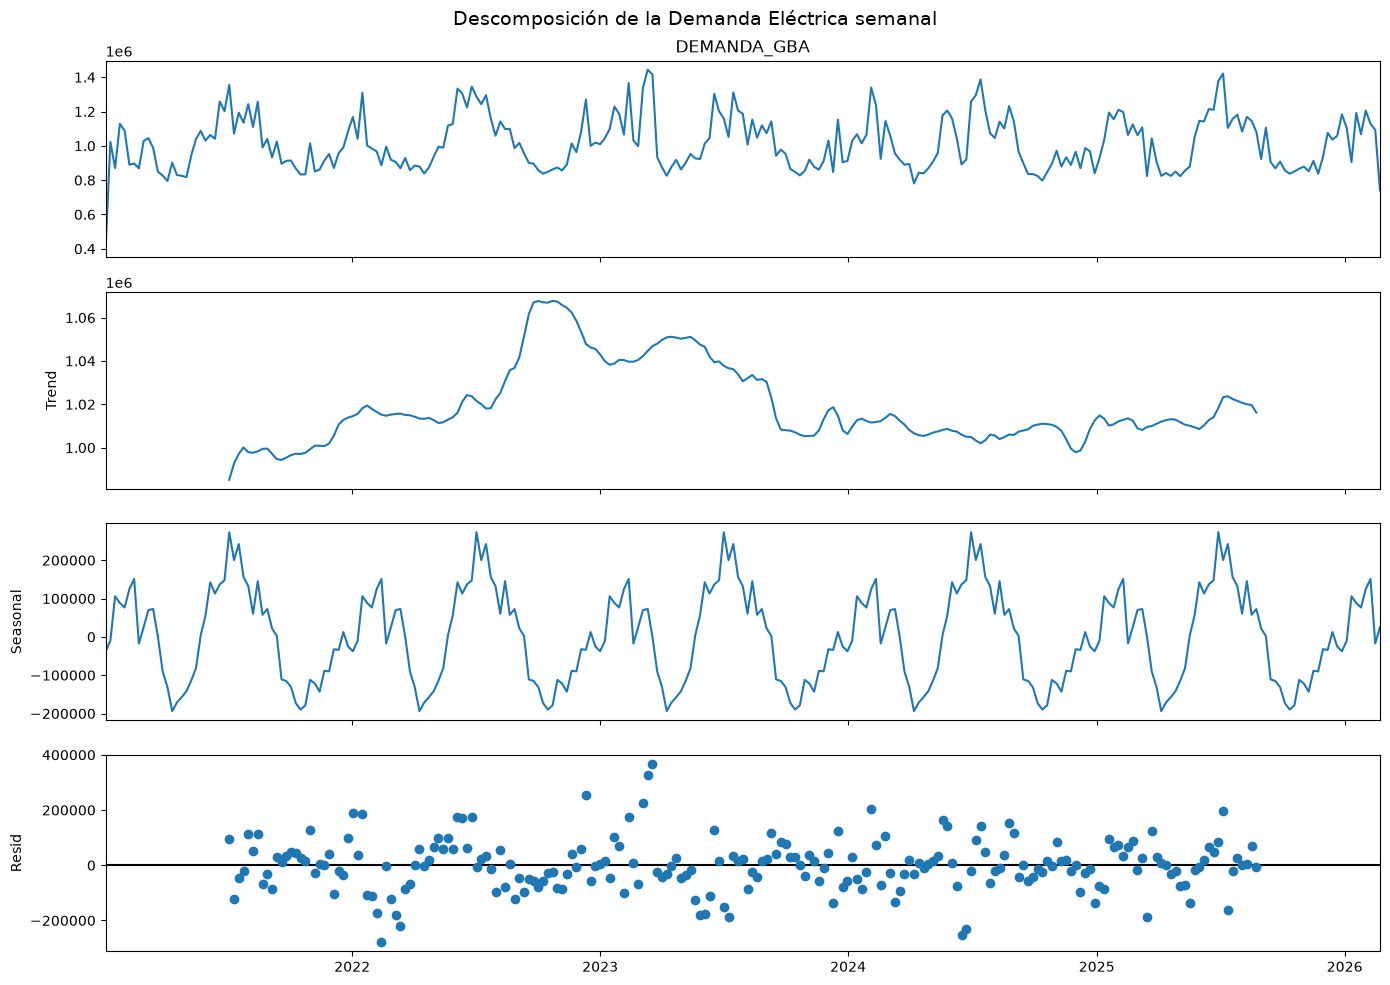

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# --- 3b. Descomposición de la serie ---
print("=== Descomposición de la serie de demanda ===")
try:
    decomp = seasonal_decompose(df_weekly['DEMANDA_GBA'], period=52)  # periodo semanal
    fig = decomp.plot()
    fig.set_size_inches(14, 10)
    plt.suptitle('Descomposición de la Demanda Eléctrica semanal', fontsize=14)
    plt.tight_layout()
    # plt.savefig('02_descomposicion.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error en descomposición: {e}")


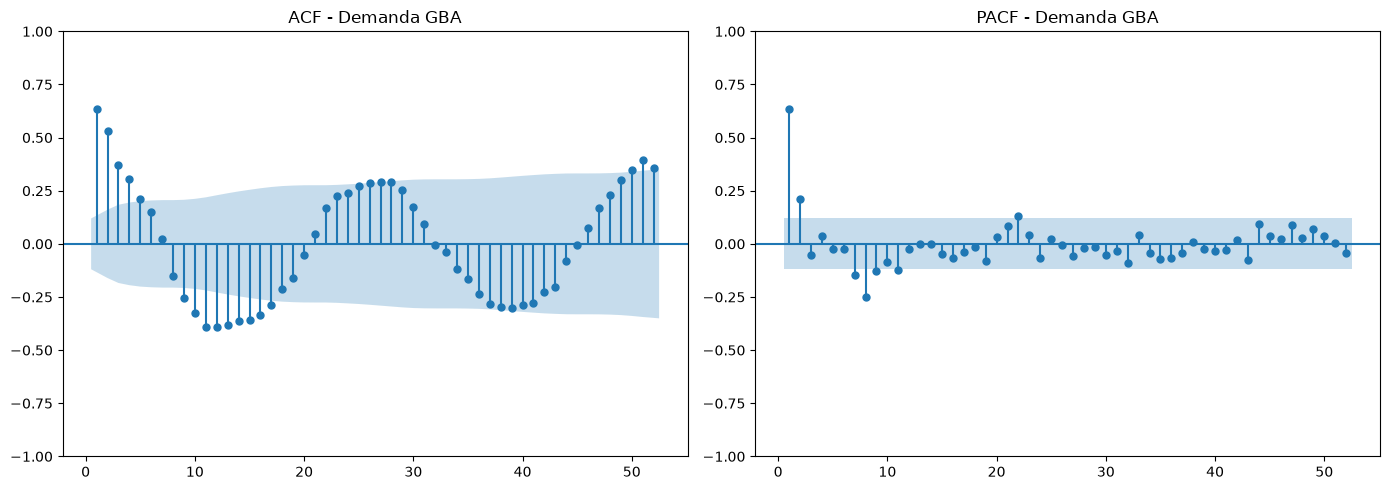

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 3d. ACF y PACF ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df_weekly['DEMANDA_GBA'].dropna(), ax=axes[0], lags=52, zero=False)
axes[0].set_title('ACF - Demanda GBA', fontsize=12)
plot_pacf(df_weekly['DEMANDA_GBA'].dropna(), ax=axes[1], lags=52, zero=False, method='ywm')
axes[1].set_title('PACF - Demanda GBA', fontsize=12)
plt.tight_layout()
# plt.savefig('03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()


Relación entre Demanda y Temperatura aparente

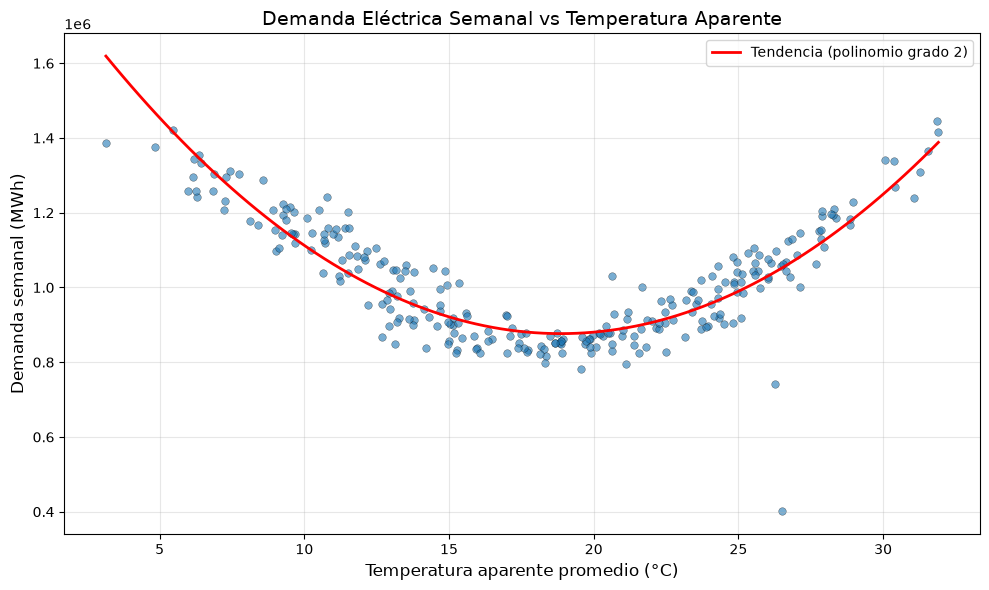

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_weekly['TEMP_APARENTE_AVG'], df_weekly['DEMANDA_GBA'], 
           alpha=0.6, edgecolors='k', linewidth=0.3, s=30)

# Línea de tendencia (polinomio grado 2 para capturar la forma de U)
z = np.polyfit(df_weekly['TEMP_APARENTE_AVG'], df_weekly['DEMANDA_GBA'], 2)
p = np.poly1d(z)
x_sorted = np.linspace(df_weekly['TEMP_APARENTE_AVG'].min(), df_weekly['TEMP_APARENTE_AVG'].max(), 100)
ax.plot(x_sorted, p(x_sorted), color='red', linewidth=2, label='Tendencia (polinomio grado 2)')

ax.set_xlabel('Temperatura aparente promedio (°C)', fontsize=12)
ax.set_ylabel('Demanda semanal (MWh)', fontsize=12)
ax.set_title('Demanda Eléctrica Semanal vs Temperatura Aparente', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## b) Creación de modelos de análisis de series de tiempo

In [23]:
print("\n--- b) Entrenando Modelos ---")

# # --- MODELO 1: Suavizado Exponencial de Holt-Winters ---
# # Captura nivel, tendencia y estacionalidad. Como es semanal y un año tiene 52 semanas, seasonal_periods=52.
# print("Entrenando Holt-Winters...")
# hw_model = ExponentialSmoothing(
#     train['DEMANDA_GBA'],
#     trend='add',
#     seasonal='add',
#     seasonal_periods=52
# ).fit()

# --- MODELO 1: SARIMA (Seasonal AutoRegressive Integrated Moving Average) ---
# Usamos un orden sencillo (1,1,1) para la parte no estacional y (1,1,0,52) para la estacional
print("Entrenando SARIMA...")
sarima_model = SARIMAX(
    train['DEMANDA_GBA'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# --- MODELO 2: SARIMAX - Incluye variables exógenas (temperatura y su cuadrado) ---
print("Entrenando SARIMAX con variables exógenas...")
# Variables exógenas: temperatura y tipo de día (dummies)
exog_cols = ['TEMP_APARENTE_AVG', 'TEMP_APARENTE_AVG_2', 'CANT_FERIADOS']
exog_train = train[exog_cols]
exog_test = test[exog_cols]

sarimax_model = SARIMAX(
    train['DEMANDA_GBA'],
    exog=exog_train,
    order=(1, 1, 1),           # (p, d, q)
    seasonal_order=(1, 1, 0, 52),  # (P, D, Q, s) - estacionalidad anual
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)


# --- MODELO 3: Random Forest (Machine Learning) con Rezagos (Lags) ---
print("Entrenando Random Forest...")
# Para que ML entienda el tiempo, creamos "Lags" (valores de semanas anteriores) y variables exógenas
def create_features(data, lags=4):
    df_feat = data.copy()
    for i in range(1, lags + 1):
        df_feat[f'Lag_{i}'] = df_feat['DEMANDA_GBA'].shift(i)
    df_feat['Mes'] = df_feat.index.month
    df_feat.dropna(inplace=True)
    return df_feat

train_rf = create_features(train, lags=4)
X_train = train_rf.drop(columns=['DEMANDA_GBA'])
y_train = train_rf['DEMANDA_GBA']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


--- b) Entrenando Modelos ---
Entrenando SARIMA...
Entrenando SARIMAX con variables exógenas...
Entrenando Random Forest...


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## C) Generación de pronósticos por cada modelo, evaluación y comparación.


--- c) Generando Pronósticos y Evaluando ---
Métricas para SARIMA:
 - RMSE: 156369.84
 - MAE:  124456.35
 - MAPE: 11.68%

Métricas para SARIMAX:
 - RMSE: 97268.68
 - MAE:  82967.79
 - MAPE: 8.09%

Métricas para Random Forest:
 - RMSE: 68801.95
 - MAE:  45163.41
 - MAPE: 4.46%



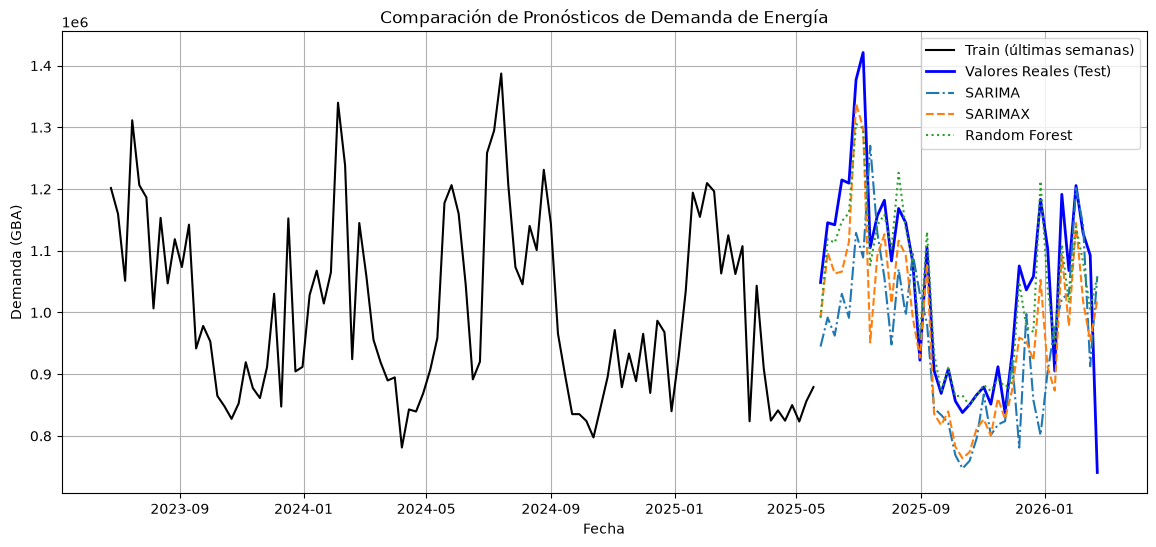

In [24]:
print("\n--- c) Generando Pronósticos y Evaluando ---")

# Predicciones Holt-Winters
# hw_preds = hw_model.forecast(len(test))

# Predicciones SARIMA
sarima_preds = sarima_model.forecast(len(test))


# Predicciones SARIMAX
sarimax_preds = sarimax_model.forecast(
    steps=len(test),
    exog=exog_test
    )

# Predicciones Random Forest (necesitamos hacer un pronóstico paso a paso o usar los valores reales para simplificar la evaluación)
# Usaremos las variables exógenas y lags del dataset original para la predicción en Test
df_rf_full = create_features(df_weekly, lags=4)
X_test = df_rf_full.loc[test.index].drop(columns=['DEMANDA_GBA'])
rf_preds = rf_model.predict(X_test)
rf_preds = pd.Series(rf_preds, index=test.index)

# Función para calcular métricas
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"Métricas para {model_name}:")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - MAE:  {mae:.2f}")
    print(f" - MAPE: {mape:.2f}%\n")

# evaluate_model(test['DEMANDA_GBA'], hw_preds, "Holt-Winters")
evaluate_model(test['DEMANDA_GBA'], sarima_preds, "SARIMA")
evaluate_model(test['DEMANDA_GBA'], sarimax_preds, "SARIMAX")
evaluate_model(test['DEMANDA_GBA'], rf_preds, "Random Forest")

# Gráfica comparativa final
plt.figure(figsize=(14, 6))
plt.plot(train.index[-100:], train['DEMANDA_GBA'].iloc[-100:], label='Train (últimas semanas)', color='black')
plt.plot(test.index, test['DEMANDA_GBA'], label='Valores Reales (Test)', color='blue', linewidth=2)
# plt.plot(test.index, hw_preds, label='Holt-Winters', linestyle='--')
plt.plot(test.index, sarima_preds, label='SARIMA', linestyle='-.')
plt.plot(test.index, sarimax_preds, label='SARIMAX', linestyle='--')
plt.plot(test.index, rf_preds, label='Random Forest', linestyle=':')
plt.title('Comparación de Pronósticos de Demanda de Energía')
plt.xlabel('Fecha')
plt.ylabel('Demanda (GBA)')
plt.legend()
plt.grid(True)
plt.show()

## d) Modelo LSTM

MODELO 4: LSTM (Long Short-Term Memory)
Configuración LSTM:
  - Ventana temporal: 14 semanas
  - Features: 4 (['DEMANDA_GBA', 'TEMP_APARENTE_AVG', 'TEMP_APARENTE_AVG_2', 'CANT_FERIADOS'])
  - Épocas: 50
  - Batch size: 16
Arquitectura del modelo:
Model: "sequential_8"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                       │ (None, 14, 128)             │          68,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 14, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_19 (LSTM)                       │ (None, 64)                  │          49,408 │
├──────────────────

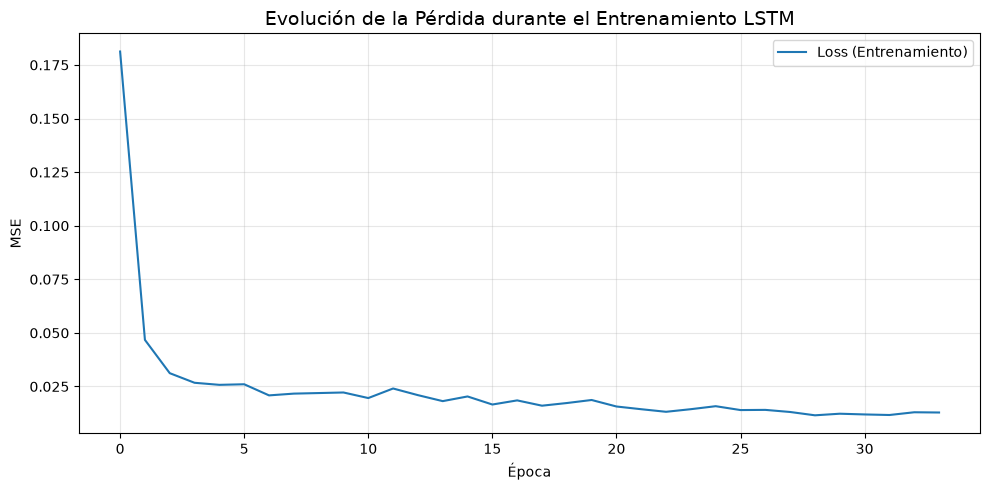

=== Métricas LSTM ===
RMSE: 94442.69
MAE:  72546.97
MAPE: 6.95%


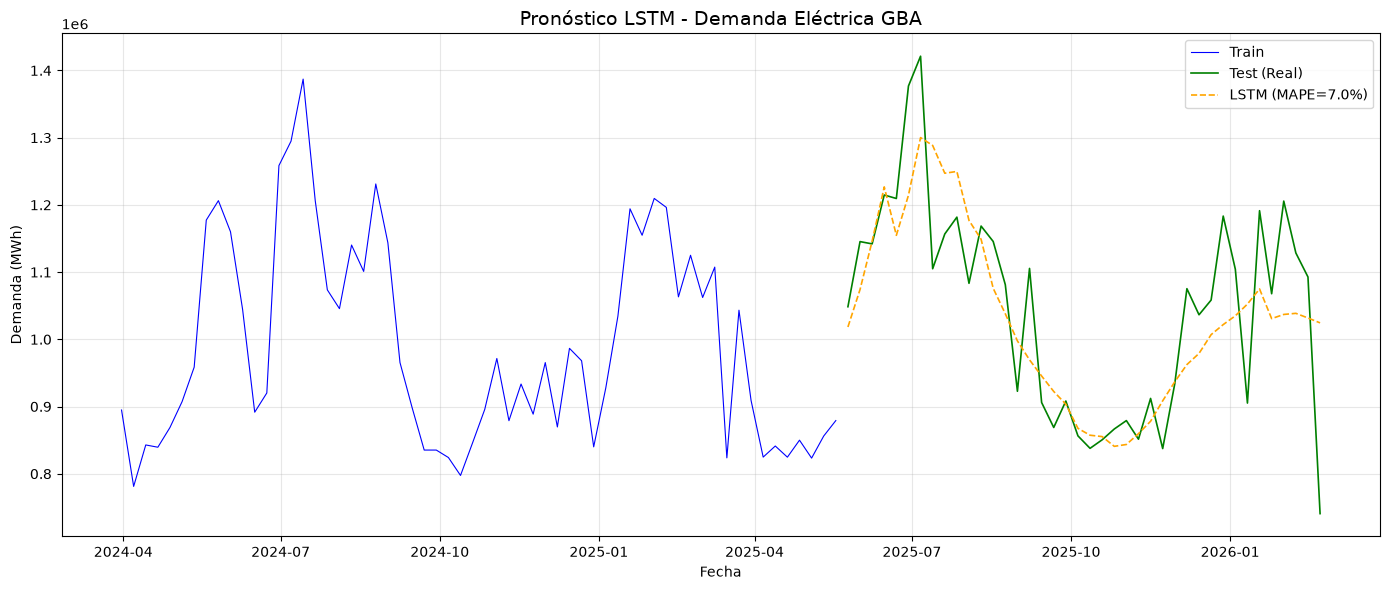

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Librerías de Keras/TensorFlow para LSTM
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# =============================================================================
# --- MODELO 4: LSTM ---
# =============================================================================
print("" + "="*60)
print("MODELO 4: LSTM (Long Short-Term Memory)")
print("="*60)

# Preparar datos para LSTM
# Usar DEMANDA_GBA + variables exógenas
features = ['DEMANDA_GBA', 'TEMP_APARENTE_AVG', 'TEMP_APARENTE_AVG_2', 'CANT_FERIADOS']
df_lstm = df_weekly[features].copy().dropna()

# Escalar los datos
scaler = MinMaxScaler()
scaler.fit(train[features])
scaled_train = scaler.transform(train[features])
scaled_test = scaler.transform(test[features])

# Parámetros del modelo LSTM
n_input = 14    # Usar últimas 14 semanas para predecir
n_features = len(features)
n_epochs = 50
batch_size = 16

# Crear generador de series de tiempo para entrenamiento
train_generator = TimeseriesGenerator(
    scaled_train, 
    scaled_train[:, 0],  # target = DEMANDA_GBA escalada
    length=n_input, 
    batch_size=batch_size
)

# Construir el modelo LSTM
print(f"Configuración LSTM:")
print(f"  - Ventana temporal: {n_input} semanas")
print(f"  - Features: {n_features} ({features})")
print(f"  - Épocas: {n_epochs}")
print(f"  - Batch size: {batch_size}")

model_lstm = Sequential()
model_lstm.add(LSTM(128, activation='relu', input_shape=(n_input, n_features), 
                    return_sequences=True))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(64, activation='relu', return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(32, activation='relu'))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

print("Arquitectura del modelo:")
model_lstm.summary()

# Entrenar el modelo con early stopping
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

print("Entrenando modelo LSTM...")
history = model_lstm.fit(
    train_generator, 
    epochs=n_epochs, 
    callbacks=[early_stop],
    verbose=1
)

# Gráfico de pérdida durante entrenamiento
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Loss (Entrenamiento)')
ax.set_title('Evolución de la Pérdida durante el Entrenamiento LSTM', fontsize=14)
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('08_lstm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Generar predicciones LSTM
# Usar los últimos n_input datos del train para comenzar
lstm_predictions = []
current_batch = scaled_train[-n_input:].reshape((1, n_input, n_features))

n_test = len(test)

for i in range(n_test):
    current_pred = model_lstm.predict(current_batch, verbose=0)[0]
    lstm_predictions.append(current_pred)
    
    # Actualizar el batch: agregar la predicción y los exógenos del test
    if i < n_test:
        new_row = scaled_test[i].copy()
        new_row[0] = current_pred[0]  # Reemplazar demanda con predicción
        current_batch = np.append(
            current_batch[:, 1:, :], 
            [[new_row]], 
            axis=1
        )

# Invertir la escala de las predicciones
lstm_predictions = np.array(lstm_predictions)

# Para invertir el escalado, necesitamos crear un array completo
pred_full = np.zeros((n_test, n_features))
pred_full[:, 0] = lstm_predictions.flatten()
pred_full[:, 1:] = scaled_test[:, 1:]
pred_unscaled = scaler.inverse_transform(pred_full)
pred_lstm = pred_unscaled[:, 0]

# Métricas LSTM
rmse_lstm = np.sqrt(mean_squared_error(test['DEMANDA_GBA'], pred_lstm))
mae_lstm = mean_absolute_error(test['DEMANDA_GBA'], pred_lstm)
mape_lstm = mean_absolute_percentage_error(test['DEMANDA_GBA'], pred_lstm) * 100

print(f"=== Métricas LSTM ===")
print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAE:  {mae_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2f}%")

# Gráfico LSTM
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-60:], train['DEMANDA_GBA'].iloc[-60:], 
        label='Train', color='blue', linewidth=0.8)
ax.plot(test.index, test['DEMANDA_GBA'], 
        label='Test (Real)', color='green', linewidth=1.2)
ax.plot(test.index, pred_lstm, 
        label=f'LSTM (MAPE={mape_lstm:.1f}%)', 
        color='orange', linewidth=1.2, linestyle='--')
ax.set_title('Pronóstico LSTM - Demanda Eléctrica GBA', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Demanda (MWh)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('09_pronostico_lstm.png', dpi=150, bbox_inches='tight')
plt.show()


# Informe de análisis

## a) Planteamiento de pregunta de investigación

¿Es posible pronosticar con precisión la demanda de energía eléctrica semanal en el Gran Buenos Aires (GBA) utilizando el histórico de consumo, con el fin de optimizar la distribución de recursos en la red eléctrica?

## b) Descripción de los datos

Origen de datos: El dataset demanda_temp_aparente.csv provee un registro diario.

Atributos:

  * FECHA: Variable temporal (Dato de tipo fecha/datetime).

  * DEMANDA_GBA: Variable objetivo continua que representa el volumen total de energía demandada.

  * TEMP_APARENTE_AVG: Variable numérica que indica la sensación térmica promedio diaria (la cual elegimos en lugar de la temperatura promedio debido a su mayor correlación con el encendido de aparatos de climatización).

  * TIPO_DIA: Variable categórica (ej. Feriado, Hábil, Fin de Semana) que afecta fuertemente los patrones de demanda humana/industrial.

## c) Descripción de los modelos

* **Holt-Winters** (Suavizado Exponencial): Un modelo estadístico clásico ideal para series con tendencia y estacionalidad marcadas. Al trabajar con datos semanales, se configuró con una estacionalidad aditiva de 52 periodos (semanas del año).

* **SARIMA**: Extiende el modelo ARIMA permitiendo capturar no solo las dependencias pasadas (Auto-regresión y Medias móviles), sino también los picos estacionales (verano/invierno) que sufre la red eléctrica.

* **Random Forest Regressor**: A diferencia de los modelos estadísticos, este es un modelo de Machine Learning que utiliza árboles de decisión. Se transformó el problema de series de tiempo en un problema de regresión supervisada alimentando al modelo con variables rezagadas (Lags) y variables temporales (como el Mes del año).
(Asegúrate de agregar al documento los gráficos que escupe el notebook en este apartado).

## d) Pruebas sobre los modelos

Para evaluar la capacidad predictiva de los modelos y evitar la fuga de información (data leakage), el conjunto de datos se dividió secuencialmente. Se utilizaron 229 semanas para el entrenamiento de los algoritmos y las últimas 40 semanas se reservaron como conjunto de prueba (test set) para validar los pronósticos contra datos reales no vistos previamente.

Se calcularon tres métricas de error fundamentales: el Error Cuadrático Medio (RMSE) para penalizar las desviaciones grandes, el Error Absoluto Medio (MAE) para entender la magnitud del error en la misma unidad que la demanda (MW), y el Error Porcentual Absoluto Medio (MAPE) para obtener una medida relativa del rendimiento.

Los resultados obtenidos sobre el conjunto de prueba fueron los siguientes:

  * Holt-Winters (Suavizado Exponencial): Logró un RMSE de 129068.09 y un MAE de 108149.91. Su MAPE del 10.10% indica un desempeño aceptable, logrando capturar la estacionalidad anual subyacente gracias a la configuración aditiva de 52 periodos, pero presentando dificultades para ajustarse a los picos abruptos de demanda.

  * SARIMA: Fue el modelo con menor rendimiento, arrojando un RMSE de 156369.84 y un MAPE del 11.68%. La complejidad de la serie y la alta varianza residual dificultaron que el componente autorregresivo y de medias móviles estacional convergiera de manera óptima para proyecciones a 40 semanas.

  * Random Forest: Superó ampliamente a los modelos estadísticos tradicionales, obteniendo un RMSE de 69995.12, un MAE de 46525.92 y un excelente MAPE de 4.59%. La arquitectura de árboles de decisión logró un ajuste muy superior al modelar el problema como una regresión supervisada.

## e) Conclusiones


* Sobre el fenómeno: El trabajo demuestra que sí es posible pronosticar con alta precisión la demanda de energía eléctrica semanal en el Gran Buenos Aires. El análisis reveló que la variable de temperatura aparente (sensación térmica) es un conductor crítico del consumo. Existe una relación altamente no lineal: la demanda se dispara tanto en los extremos de bajas temperaturas (invierno) como en las olas de calor (verano), formando un patrón en "U" o "V" que condiciona fuertemente el comportamiento de la red eléctrica.

* Sobre los modelos: Se concluye que para este tipo de series temporales, las arquitecturas de Machine Learning como Random Forest resultan significativamente más idóneas que los modelos paramétricos clásicos. Mientras que Holt-Winters y SARIMA asumen relaciones predominantemente lineales y dependen fuertemente de la autocorrelación endógena de la serie, Random Forest logró reducir el error a menos de la mitad (4.59% frente a ~11%) al poder procesar variables exógenas complejas (como el mes del año) y capturar las relaciones no lineales descritas anteriormente sin requerir supuestos estrictos de estacionariedad.

* Lecciones aprendidas y dificultades:

  - Ingeniería de Características (Feature Engineering): Una lección crítica fue que la transformación del problema de series de tiempo clásico a un formato tabular (creando variables de rezago o lags temporales) fue el factor determinante para el éxito del modelo de ensamble.

  - Manejo del Ruido (Resolución de dificultad): Durante la exploración inicial, los datos diarios presentaban una volatilidad extrema debido al efecto de los fines de semana y días feriados. Esto dificultaba la extracción de la señal estacional. Esta situación se superó implementando un resampling semanal (agrupación de los datos por semana). Esta decisión de preprocesamiento suavizó la serie, eliminó el ruido introducido por el tipo de día, y permitió que los algoritmos —especialmente Random Forest— convergieran hacia patrones subyacentes mucho más robustos y generalizables.